In [1]:
import pandas as pd

# Loading the dataset
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
# Preparing X variables
X = df.drop("math_score", axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [3]:
# Unique categories in categorical columns
print(f"Categories in 'gender' column: {df['gender'].unique()}")
print("-"*70)
print(f"Categories in 'race/ethnicity' column: {df['race_ethnicity'].unique()}")
print("-"*70)
print(f"Categories in 'parental education' column: {df['parental_level_of_education'].unique()}")
print("-"*70)
print(f"Categories in 'lunch' column: {df['lunch'].unique()}")
print("-"*70)
print(f"Categories in 'test preparation course' column: {df['test_preparation_course'].unique()}")

Categories in 'gender' column: <StringArray>
['female', 'male']
Length: 2, dtype: str
----------------------------------------------------------------------
Categories in 'race/ethnicity' column: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
----------------------------------------------------------------------
Categories in 'parental education' column: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
----------------------------------------------------------------------
Categories in 'lunch' column: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
----------------------------------------------------------------------
Categories in 'test preparation course' column: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [5]:
# Preparing the depending variable
Y = df["math_score"]
print(Y)

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64


In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Creating the column transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="str").columns
cat_features = X.select_dtypes(include="str").columns

num_transformer, ohe_transformer = StandardScaler(), OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHot Encoder", ohe_transformer, cat_features),
        ("Standard Scaler", num_transformer, num_features)
    ]
)

X = preprocessor.fit_transform(X)
print(X.shape)

# Separating the dataset into the training dataset and testing dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
print(X_train.shape, X_test.shape)

(1000, 19)
(700, 19) (300, 19)


In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creating an Evaluate Function to give all metrics after model Training
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    R2_score = r2_score(true, predicted)
    return mae, rmse, R2_score

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Support Vector Regressor": SVR(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "XGBRegressor": XGBRegressor()
}

model_list, r2_list = list(), list()

for name, model in models.items():
    # Model Training
    model.fit(X_train, Y_train)
    
    # Make predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(Y_train, Y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(Y_test, Y_test_pred)
    
    model_list.append(name)
    print(name)
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    print('-'*38)
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print('='*38)
    print()

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2483
- Mean Absolute Error: 4.1985
- R2 Score: 0.8751
--------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5576
- Mean Absolute Error: 4.4183
- R2 Score: 0.8759

Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5106
- Mean Absolute Error: 5.1582
- R2 Score: 0.8078
--------------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.8705
- Mean Absolute Error: 5.3929
- R2 Score: 0.8103

Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2487
- Mean Absolute Error: 4.1977
- R2 Score: 0.8751
--------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5566
- Mean Absolute Error: 4.4155
- R2 Score: 0.8759

Support Vector Regressor
Model performance for Training set
- Root Mean Squared Error: 6.7557
- Mean Absolute Error: 4.9467
- R2 Score: 0.7931
-----------

In [16]:
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(
    by=["R2_Score"],
    ascending=False
)

,Model Name,R2_Score
2,Ridge,0.875907
0,Linear Regression,0.875863
8,CatBoosting Regressor,0.852108
6,Random Forest Regressor,0.849334
7,AdaBoost Regressor,0.831748
9,XGBRegressor,0.811816
1,Lasso,0.810281
4,K-Neighbors Regressor,0.772328
5,Decision Tree,0.734832
3,Support Vector Regressor,0.726848


In [10]:
from sklearn.model_selection import GridSearchCV

# Setting the parameters
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Operating the grid search
grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

# Grid search results
print(grid_search.best_params_)
print(grid_search.best_score_)

{'alpha': 1}
0.8665912708061244


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Random Forest Parameters
rf_param_distributions = {
    'n_estimators': randint(200, 1000),
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 40],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap': [True, False]
}

# Catboost Parameters
cat_param_distributions = {
    'iterations': randint(300, 1500),
    'learning_rate': uniform(0.01, 0.19),
    'depth': randint(4, 11),
    'l2_leaf_reg': randint(1, 10),
    'random_strength': uniform(0, 2)
}

# All Models
random_cv_models = [
    ("RFR", RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_distributions),
    ("CBR", CatBoostRegressor(loss_function='RMSE', verbose=0, random_seed=42), cat_param_distributions)
]

# Operating the randomizedsearhcv
random_search_results = {}
for name, model, params in random_cv_models:
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    random_search.fit(X_train, Y_train)
    
    # Storing the best results
    random_search_results[name] = random_search
    
    # Results
    print(f"------------- Best Params for {name} ----------------")
    print("Best Parameters:")
    print(random_search.best_params_)
    print("\nBest CV R2:")
    print(random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
------------- Best Params for RFR ----------------
Best Parameters:
{'bootstrap': True, 'max_depth': 40, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 578}

Best CV R2:
0.8387489881591609
Fitting 5 folds for each of 100 candidates, totalling 500 fits
------------- Best Params for CBR ----------------
Best Parameters:
{'depth': 4, 'iterations': 947, 'l2_leaf_reg': 8, 'learning_rate': np.float64(0.012675166315866047), 'random_strength': np.float64(0.3976848081776103)}

Best CV R2:
0.8553166233918119


In [15]:
# Getting the best estimates
best_rf = random_search_results["RFR"].best_estimator_
best_catboost = random_search_results["CBR"].best_estimator_

models = {
    "Ridge": grid_search.best_estimator_,
    "Random Forest": best_rf,
    "CatBoost": best_catboost
}

for name, model in models.items():

    Y_pred = model.predict(X_test)

    print(f"{name}")
    print("R2:", r2_score(Y_test, Y_pred))
    print("RMSE:", mean_squared_error(Y_test, Y_pred) ** 0.5)
    print("MAE:", mean_absolute_error(Y_test, Y_pred))
    print("="*30)

Ridge
R2: 0.8759067784434539
RMSE: 5.556591731362339
MAE: 4.415505801902555
Random Forest
R2: 0.8515839605544274
RMSE: 6.076799085226596
MAE: 4.7391168184262975
CatBoost
R2: 0.8671442950149202
RMSE: 5.749426982153064
MAE: 4.4973958686167474


# Chosen Model: Ridge Regressor

In [21]:
# Final Training
ridge_model = grid_search.best_estimator_
ridge_model.fit(X_train, Y_train)
Y_pred = ridge_model.predict(X_test)
score = r2_score(Y_test, Y_pred)*100
print("Accuracy of the model is {:.2f} %".format(score))

Accuracy of the model is 87.59 %


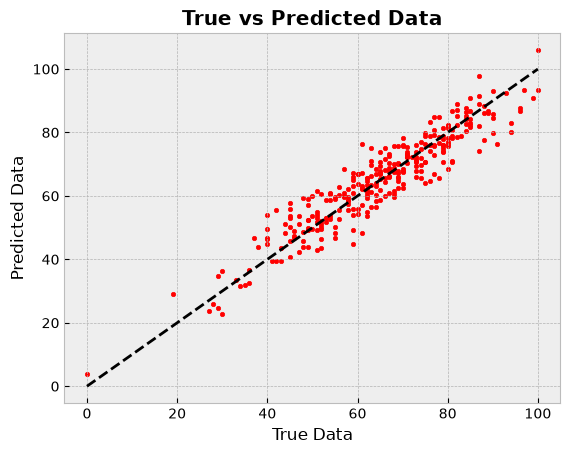

In [33]:
import matplotlib.pyplot as plt

plt.style.use("bmh")

plt.scatter(Y_test, Y_pred, s=10, color="red")

# Ideal prediction line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linestyle='--',
    color="black"
)

plt.title("True vs Predicted Data", weight="bold")
plt.xlabel("True Data")
plt.ylabel("Predicted Data")

plt.show()

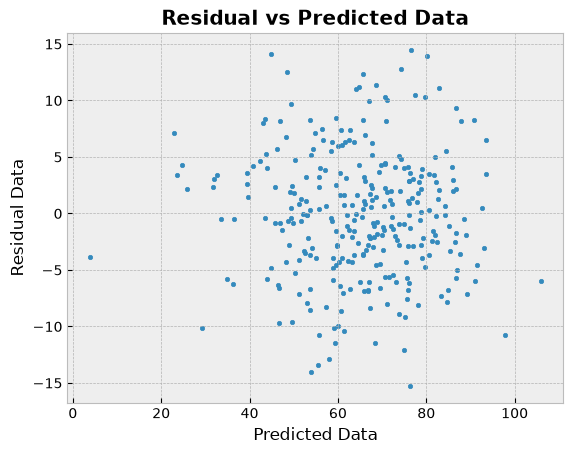

In [36]:
# Creating a residual plot
pred_df = pd.DataFrame(
    {
        'Actual Value': Y_test,
        'Predicted Value': Y_pred,
        'Difference': Y_test - Y_pred
    }
)

plt.scatter(x=pred_df["Predicted Value"], y=pred_df["Difference"], s=10)
plt.title("Residual vs Predicted Data", weight="bold")
plt.xlabel("Predicted Data")
plt.ylabel("Residual Data")

plt.show()